## 이미지를 텍스트로 검색/생성 RAG

In [2]:
%pip install -Uq langchain langchain-openai langchain-chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6

In [7]:
# 구글드라이브 연동
from google.colab import drive
drive.mount('/content/drive')  # 내 구글 드라이브를 /content/drive 경로로 마운트

BASE_PATH = '/content/drive/MyDrive/05_multimodal_rag' # 기본 작업 경로 변수


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
from google.colab import userdata

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')
os.environ['LANGSMITH_PROJECT'] = 'skn23-multimodal-rag'
os.environ['OPENAI_API_KEY'] = userdata.get("OPENAI_API_KEY")

## 이미지 캡셔닝 & 벡터 DB 저장

In [9]:
# 이미지 파일을 Base64 문자열로 변환하는 함수
import base64 # 바이너리 데이터를 Base64 문자열로 인코딩 모듈
from PIL import Image # 이미지 처리

# 이미지 파일을 Base64 문자열로 변환하는 함수
def image_to_base64(image_path):
  with open(image_path, 'rb') as f:  # 이미지를 바이너리 읽기 모드로 열기
    encoded = base64.b64encode(f.read()).decode('utf-8') # 베이스64 인코딩 후 문자열로 변환
  return encoded  # 인코딩된 문자열 반환

- 이렇게 인코딩된 문자열은 json의 값으로 보내면 이미지를 보낼떄 매우 편하게 보낼 수 있다.

In [10]:
from openai import OpenAI

client = OpenAI()  # OpenAI 클라이언트 객체

# 이미지 파일을 받아 안전교육 및 화재대피 관점에서 요약하는 함수
def summarize_image(image_path):
  encoded = image_to_base64(image_path)

  # Chat Completions API 호출
  response = client.chat.completions.create(
    model='gpt-4.1-mini',
    messages = [
            {
                'role': 'system',
                'content': '''
아래 아미지를 안전교육 및 화재대피 관점에서
주제문구와 각 장면에 대한 정보를 빠짐없이 한국어로 설명해주세요.
'''  # 모델에게 부여하는 지침(역할 및 설명 방식 정의)
            },
            {
            'role': 'user',
            'content': [{
                'type': 'image_url',  # 이미지 입력 타입 지정
                'image_url': {
                    'url': f'data:image/jpeg;base64,{encoded}'  # Base64 인코딩된 이미지 전달
                            }
                        }]
            }
        ],
        max_tokens = 1024   # 최대 생성 토큰 수
  )
  return response.choices[0].message.content  # 모델이 생성한 텍스트 응답

print(summarize_image(f'{BASE_PATH}/figures/figure-1.jpg'))

이 이미지는 완강기 사용 방법, 즉 화재 발생 시 안전하게 대피할 수 있는 '완강기' 사용법을 안내하는 안전교육 자료입니다. 

주제문구:  
- "완강기 사용 방법" (한글)  
- "FIRE ESCAPE DEVICE" (영어)  

각 장면별 설명:  

1. 후크를 고리에 안전하게 건다.  
   - 완강기의 후크를 건물 벽면에 설치된 고리에 단단히 고정합니다.  
   - 그림에서는 후크를 고리에 걸고 있는 모습을 보여줍니다.  

2. 리일(줄)을 창밖으로 던진다.  
   - 완강기의 줄(reel)을 창문 밖으로 내던져 줄을 바깥쪽으로 펼쳐 놓습니다.  
   - 그림에는 사람이 창문 밖으로 줄을 던지는 장면이 묘사되어 있습니다.  

3. 벨트를 가슴에 안전하게 맨다.  
   - 완강기의 안전벨트를 몸에 고정하여 사용 중 떨어지지 않도록 합니다.  
   - 그림에서는 사람이 벨트를 가슴 부위에 조이며 착용하는 모습이 보입니다.  

4. 벽면을 안전하게 타고 내려간다.  
   - 완강기를 이용해 벽면을 따라 천천히 아래로 내려갑니다.  
   - 그림은 사람이 완강기를 타고 벽을 내려가는 장면입니다.  

이 안내문은 화재 및 비상 상황 시 신속하고 안전하게 완강기를 사용해 고층 건물에서 대피할 수 있도록 돕는 중요한 안전 수칙을 설명하고 있습니다.


In [11]:
from langchain_chroma.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from tqdm.auto import tqdm
import os

persistent_dir = f'{BASE_PATH}/chroma' # 벡터 DB 저장 경로

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')   # OpenAI 임베딩 모델 객체
vector_db = Chroma(
    collection_name = 'mutimodal_rag',  # 컬렉션(테이블) 이름
    embedding_function = embeddings,    # 임베딩 함수 연결
    persist_directory = persistent_dir  # 디스크 저장 경로
)

In [12]:
figure_dir = os.path.join(BASE_PATH, 'figures')  # 이미지 폴더 경로

image_files = [
    os.path.join(figure_dir, filename)      # 전체 경로 저장
    for filename in os.listdir(figure_dir)  # 폴더 내 파일 목록 순회
    if filename.lower().endswith('.jpg')    # 확장자가 .jpg 파일
]

for img_path in tqdm(image_files):
  b64_str = image_to_base64(img_path)     # 이미지 Base64 인코딩
  caption = summarize_image(img_path)     # 이미지 요약 생성
  vector_db.add_texts(
      texts= [caption],   # 벡터화해서 저장
      metadatas = [       # 메타데이터 저장
          {'base64_image' : b64_str,
           'image_path' : img_path}
          ]
  )

  0%|          | 0/3 [00:00<?, ?it/s]

In [13]:
docs = vector_db._collection.get()  # 컬렉션에 저장된 전체 문서 및 메타데이터

# 문서와 메타데이터를 함꼐 순회하면서 출력
for i, (page_content, metadata) in enumerate(zip(docs['documents'], docs['metadatas'])):
  print(f'[{i+1}]')
  print(f'{page_content =}')
  print(f'{metadata =}')
  print()

[1]
page_content ='이 이미지는 \'완강기 사용 방법\'을 안내하는 안전교육 및 화재대피 관련 안내문입니다. 완강기는 화재 등 비상 상황 시 높은 층에서 안전하게 대피할 수 있도록 돕는 구조 장비입니다. \n\n주제문구:\n- "완강기 사용 방법"\n- "FIRE ESCAPE DEVICE"\n\n각 장면별 정보:\n\n1. 후크를 고리에 안전하게 건다.\n   - 완강기 후크를 건물의 안전한 고정용 고리에 단단히 걸어야 함을 나타냅니다.\n   - 그림은 고리에 후크를 걸고 있는 모습을 보여줍니다.\n\n2. 리일(줄)을 창밖으로 던진다.\n   - 완강기의 줄을 창 밖으로 던져 외부로 길게 펼쳐 내려 보낼 것을 안내합니다.\n   - 그림에는 사람이 창문 밖으로 줄을 던지는 모습이 있습니다.\n\n3. 벨트를 가슴에 안전하게 맨다.\n   - 벨트를 몸에 꼭 맞게 착용하여 안전하게 하강할 준비를 해야 함을 설명합니다.\n   - 그림에는 벨트를 착용 중인 사람이 표시되어 있습니다.\n\n4. 벽면을 안전하게 타고 내려간다.\n   - 몸을 벽 쪽으로 향하게 하여 천천히 조심스럽게 아래로 내려가도록 안내합니다.\n   - 그림에는 벽에 기대어 내려가는 사람이 나타나 있습니다.\n\n요약하자면, 이 표는 완강기의 올바른 사용법을 4단계로 나누어 이미지와 함께 설명하여 화재 시 안전한 대피를 돕는 내용입니다.'
metadata =None

[2]
page_content ='이 이미지는 화재대피 시 사용하는 완강기 사용 방법에 관한 안전교육 안내문입니다. 주제문구는 "완강기 사용 방법"과 영어로 "FIRE ESCAPE DEVICE"로 명확히 표시되어 있습니다.\n\n각 장면에 대한 설명은 다음과 같습니다:\n\n1. 첫 번째 장면:  \n   - 설명: "후크를 고리에 안전하게 건다."  \n   - 그림: 후크를 눈볼트(고리)에 단단히 걸고 있는 모습을 그림으로 표시.  \n   - 의미: 완강기의 후크를 안전한 고리에 견고하게 연결하는 첫 단계입니

In [14]:
from io import BytesIO # 바이트 데이터를 메모리 파일처럼 다루기 위한 모듈
from PIL import Image

# Base64문자열 -> 이미지로 화면 출력하는 함수
def show_base64_image(b64_str):
  img = Image.open(BytesIO(base64.b64decode(b64_str)))  # Base64 디코딩 후 이미지 객체 생성
  display(img)

show_base64_image(docs['metadatas'][0]['base64_image'])  # [0] : 첫번째 이미지, [1] : 두번쨰 이미지, [2] : 세번째 이미지

TypeError: 'NoneType' object is not subscriptable

In [ ]:
# 벡터 DB 유사도 검색 후 이미지 및 캡션 출력
query = '소화기 어떻게 써야돼?'
docs = vector_db.similarity_search(query, k=2)

for i, doc in enumerate(docs):
  print(f'[{i+1}]\n {doc.page_content}')
  show_base64_image(doc.metadata['base64_image'])

## Multimodal RAG 구현
- agentic rag 구현 (middleware 기반 검색된 문서 제공)
- text + image 응답

화재 시 대피 요령은 다음과 같이 정리할 수 있습니다.

---

### 1. 코와 입을 손수건 등으로 막기  
- 연기와 유해가스 흡입을 최소화하기 위해 손수건이나 옷으로 코와 입을 감쌉니다.

### 2. 자세를 낮추기  
- 연기는 위로 올라가기 때문에, 자세를 낮춰서 연기가 적은 아래쪽 공기를 이용하며 숨을 쉽니다.

### 3. 벽을 잡고 이동하기  
- 연기로 시야가 흐려질 때 안전한 이동을 위해 한 손으로 벽을 짚으며 움직입니다.

### 4. 한 방향으로 신속히 대피하기  
- 혼란을 피하고 빠르게 밖으로 나가기 위해 한 방향으로 신속히 이동합니다.

---

### 화재 대피 시 주의사항  
- **엘리베이터 사용 금지**  
  화재 발생 시 엘리베이터가 고장 나거나 갇힐 위험이 있으므로 절대 사용하지 않습니다.  
- **숨지 말고 빠르게 대피**  
  무섭다고 숨거나 숨는 행동은 오히려 위험하므로 침착하게 신속히 대피하는 것이 중요합니다.

---

이상은 인천남동소방서에서 제공한 화재대피 안전교육 자료에 근거한 대피 요령입니다. 안전한 대피를 위해 반드시 숙지하고 실천해야 합니다.
[검색된 내용]


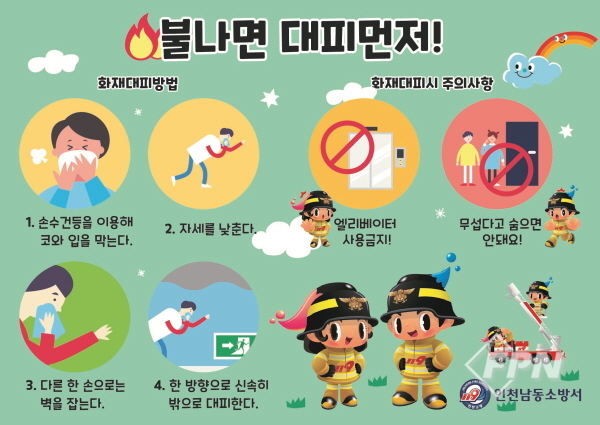

이 이미지는 화재가 발생했을 때 안전하게 대피하는 방법과 주의사항을 안내하는 교육 자료입니다.

주제문구:  
"🔥불나면 대피먼저!"

**화재대피방법**  
1. 손수건 등을 이용해 코와 입을 막는다. (연기 흡입 방지)  
2. 자세를 낮춘다. (연기보다 아래쪽 공기를 이용)  
3. 다른 한 손으로는 벽을 잡는다. (안전한 이동을 위해)  
4. 한 방향으로 신속히 밖으로 대피한다. (혼란 없이 빠르게 대피)

**화재대피 시 주의사항**  
- 엘리베이터 사용 금지! (정전 등 위험 이유)  
- 무섭다고 숨으면 안 돼요! (숨지 말고 빠르게 대피 필요)

이미지에는 소방관 캐릭터들이 대피방법을 친절하게 설명하고 있으며, 피난구와 사다리차 사진으로 대피 상황을 시각적으로 표현해 이해를 돕고 있습니다.

이 교육 자료는 화재 시 대처 요령을 숙지하여 인명 피해를 최소화하는 데 목적이 있습니다.


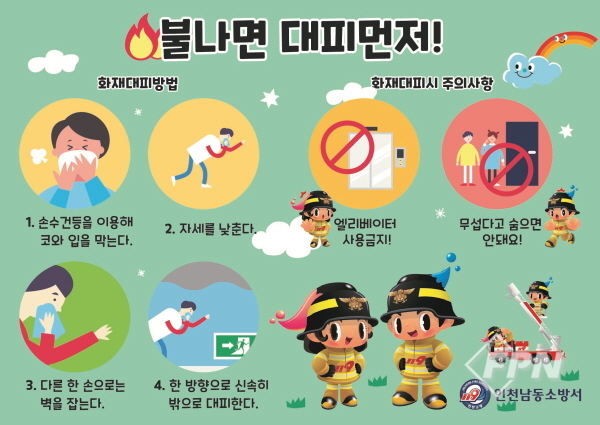

이 이미지는 화재 발생 시 안전한 대피 방법과 주의사항을 안내하는 내용으로, 주제문구는 "🔥불나면 대피먼저!"입니다.

[화재대피방법]
1. 손수건 등으로 코와 입을 막는다.
   - 연기나 유해가스 흡입을 최소화하기 위해 손수건이나 옷으로 코와 입을 감싸는 모습을 보여줍니다.
2. 자세를 낮춘다.
   - 연기는 위로 올라가기 때문에 자세를 낮춰서 연기 흡입을 줄이도록 합니다.
3. 다른 한 손으로는 벽을 짚는다.
   - 연기 때문에 시야가 나쁠 때 벽을 짚고 이동하면 더 안전하게 대피할 수 있습니다.
4. 한 방향으로 신속히 밖으로 대피한다.
   - 혼란을 줄이고 안전하게 대피하기 위해 한 방향으로 빠르게 이동하도록 안내합니다.

[화재대피시 주의사항]
- 엘리베이터 사용금지!
  엘리베이터는 화재 시 고장이 나거나 갇힐 위험이 있어 사용하지 말아야 합니다.
- 무섭다고 숨으면 안돼요!
  불안해서 숨는 행동은 오히려 위험하므로 침착하게 대피해야 합니다.

이미지에는 인천남동소방서의 귀여운 소방관 캐릭터들이 등장하여 화재대피 방법과 주의사항을 친숙하고 이해하기 쉽게 설명하고 있습니다.

이 자료는 화재 발생 시 안전한 대피 행동을 촉구하며, 연기 속에서 어떻게 행동해야 하는지를 집중적으로 안내하는 안전교육 자료임을 알 수 있습니다.


In [16]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, AgentState
from langchain_core.documents import Document
from typing import Any

class State(AgentState):
  context : list[Document]

class RetrieveDocumentsMiddleware(AgentMiddleware[State]):
  state_schema = State

  def before_model(self, state: AgentState) -> dict[str, Any] | None:
    last_message = state['messages'][-1]
    retrieved_docs = vector_db.similarity_search(last_message.text, k=2)

    docs_content = '\n\n'.join(doc.page_content for doc in retrieved_docs)

    prompt = f"""
제공된 '참조 문서'의 내용을 바탕으로 '사용자 질문'에 대해 상세히 답변하라.

제약 조건:
- 답변은 반드시 제공된 문서 내의 정보만을 근거로 작성한다.
- 문서에서 답을 찾을 수 없는 경우, "제공된 정보에서는 해당 내용을 확인할 수 없습니다"라고 답변한다.
- 논리적이고 가독성이 좋게 구조화하여 설명한다.

참조 문서:
{docs_content}

사용자 질문:
{last_message.text}
"""
    return {
        "messages" : [last_message.model_copy(update = {'content' : prompt})],
        "context" : retrieved_docs
   }

llm = init_chat_model('openai:gpt-4.1-mini')
agent = create_agent(
    llm,
    tools = [],
    middleware = [RetrieveDocumentsMiddleware()]
)

response = agent.invoke({
    'messages' : [
    ('human', '화재 시 대피 요령은 어떻게 돼?')
    ]
})

print(response['messages'][-1].content)

print('[검색된 내용]')
for doc in response['context']:
  show_base64_image(doc.metadata['base64_image'])
  print(doc.page_content)